# Variogram Diagnostics

Goodness-of-fit analysis of the 9 theoretical variogram models (3 transforms x 3 models) fitted to the pooled empirical variogram from 1961-2023.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../../results"

with open(f"{RESULTS_DIR}/ordinary_kriging/global_variograms.pkl", "rb") as f:
    data = pickle.load(f)

empirical = data["empirical"]
fitted = data["variograms"]
lag_centers_km = data["lag_centers_km"]

transforms = sorted({k[0] for k in fitted if k[0] != "indicator"})
models = sorted({k[1] for k in fitted if k[0] != "indicator"})

print(f"Transforms: {transforms}")
print(f"Models:     {models}")
print(f"Lag bins:   {len(lag_centers_km)}, range 0-{lag_centers_km[-1]:.0f} km")

# Variogram model functions (analytical)
def spherical(h, nugget, psill, a):
    h = np.asarray(h, dtype=float)
    r = h / a
    return np.where(h <= a, nugget + psill * (1.5 * r - 0.5 * r**3), nugget + psill)

def exponential(h, nugget, psill, a):
    return nugget + psill * (1.0 - np.exp(-h / a))

def gaussian(h, nugget, psill, a):
    return nugget + psill * (1.0 - np.exp(-(h / a)**2))

VGM_FN = {"spherical": spherical, "exponential": exponential, "gaussian": gaussian}
MODEL_COLORS = {"spherical": "#2196F3", "exponential": "#F44336", "gaussian": "#4CAF50"}
MODEL_LS = {"spherical": "-", "exponential": "--", "gaussian": ":"}
TRANSFORM_LABELS = {"none": "No transform (raw quota)", "log": "Log transform", "normal_score": "Normal score"}

Transforms: ['log', 'none', 'normal_score']
Models:     ['exponential', 'gaussian', 'spherical']
Lag bins:   38, range 0-411 km


## 1. Chi-square goodness of fit

chi2_red = sum((gamma_emp - gamma_model)^2 * N_i) / (n_bins - 3). Lower = better fit within each transform. Not comparable across transforms due to different semivariance scales.

In [2]:
rows = []
for tr in transforms:
    for vm in models:
        info = fitted.get((tr, vm))
        if info is None:
            rows.append({"transform": tr, "model": vm, "chi2_reduced": None,
                         "nugget": None, "psill": None, "range_km": None})
        else:
            p = info["params_dict"]
            rows.append({
                "transform": tr, "model": vm,
                "chi2_reduced": info.get("chi2_reduced"),
                "nugget": p["nugget"], "psill": p["psill"],
                "range_km": p["range"] / 1000.0,
            })

df = pd.DataFrame(rows)
df["sill"] = df["nugget"] + df["psill"]
df["nugget_ratio"] = df["nugget"] / df["sill"]

# Chi-square pivot
chi2_pivot = df.pivot(index="transform", columns="model", values="chi2_reduced")
chi2_pivot = chi2_pivot.reindex(index=["none", "log", "normal_score"],
                                 columns=["spherical", "exponential", "gaussian"])

print("chi2_reduced (lower = better fit, comparable only within each row)")
print("=" * 55)
for tr in chi2_pivot.index:
    vals = chi2_pivot.loc[tr]
    best = vals.idxmin()
    parts = [f"{vm}: {vals[vm]:>12.1f}" + (" *" if vm == best else "  ") for vm in chi2_pivot.columns]
    print(f"  {tr:<14} " + "  ".join(parts))

chi2_reduced (lower = better fit, comparable only within each row)
  none           spherical:         13.5    exponential:         11.9 *  gaussian:         21.3  
  log            spherical:     193755.7    exponential:      31177.0 *  gaussian:     349099.5  
  normal_score   spherical:     202196.5    exponential:      38392.0 *  gaussian:     383300.9  


## 2. Empirical vs theoretical variograms

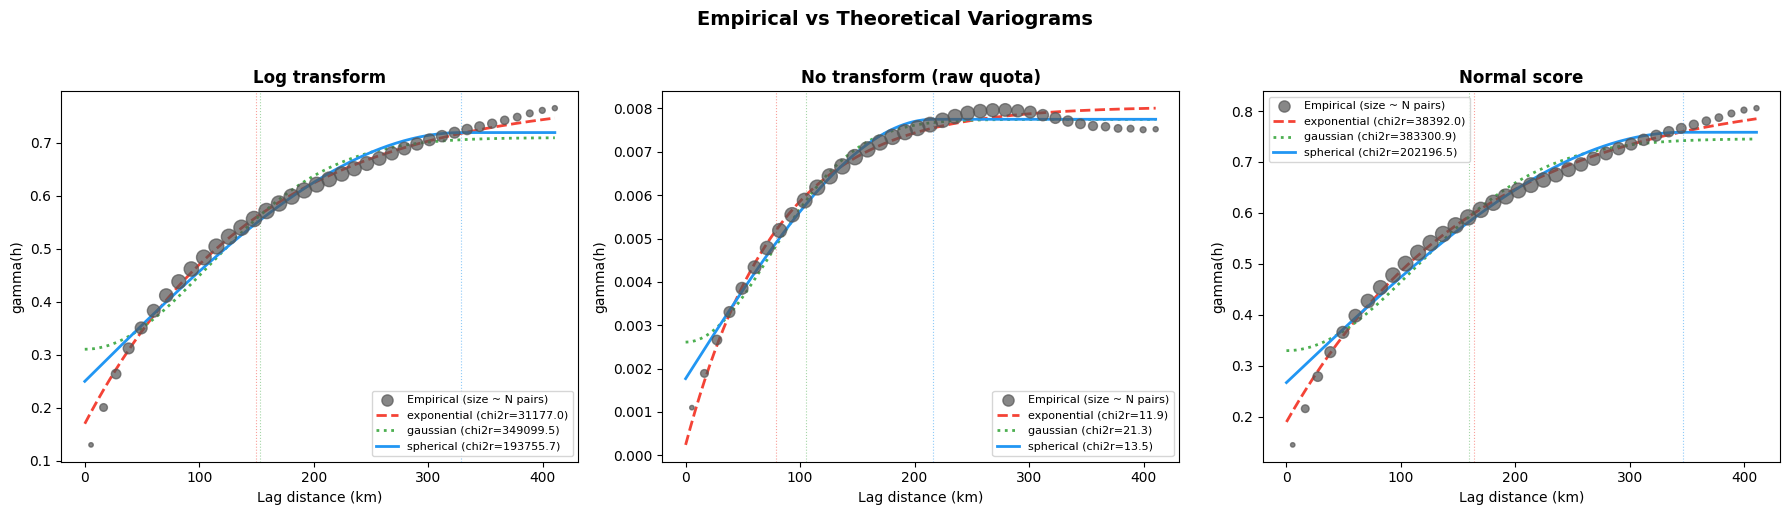

In [3]:
def eval_model(model_name, params_dict, h_km):
    p = params_dict
    h_m = h_km * 1000.0
    return VGM_FN[model_name](h_m, p["nugget"], p["psill"], p["range"])

fig, axes = plt.subplots(1, len(transforms), figsize=(6 * len(transforms), 5), sharey=False)

for ax, tr in zip(axes, transforms):
    emp = empirical[tr]
    lag_km = emp["lag_km"]
    gamma = emp["gamma"]
    count = emp["count"]
    mask = np.isfinite(gamma)
    sizes = np.clip(count[mask] / count[mask].max() * 120, 10, 120)
    ax.scatter(lag_km[mask], gamma[mask], s=sizes, c="#555", alpha=0.7, zorder=5,
               label="Empirical (size ~ N pairs)")

    h_smooth = np.linspace(0, lag_km[-1], 300)
    for vm in models:
        info = fitted.get((tr, vm))
        if info is None:
            continue
        gamma_model = eval_model(vm, info["params_dict"], h_smooth)
        chi2 = info.get("chi2_reduced")
        label = f"{vm} (chi2r={chi2:.1f})" if chi2 is not None else vm
        ax.plot(h_smooth, gamma_model, color=MODEL_COLORS[vm], ls=MODEL_LS[vm], lw=2.0, label=label)
        ax.axvline(info["params_dict"]["range"] / 1000, color=MODEL_COLORS[vm], ls=":", lw=0.8, alpha=0.5)

    ax.set_title(TRANSFORM_LABELS.get(tr, tr), fontsize=12, fontweight="bold")
    ax.set_xlabel("Lag distance (km)")
    ax.set_ylabel("gamma(h)")
    ax.legend(fontsize=8)

fig.suptitle("Empirical vs Theoretical Variograms", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../../images/variogram_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. All 9 fits: individual panels

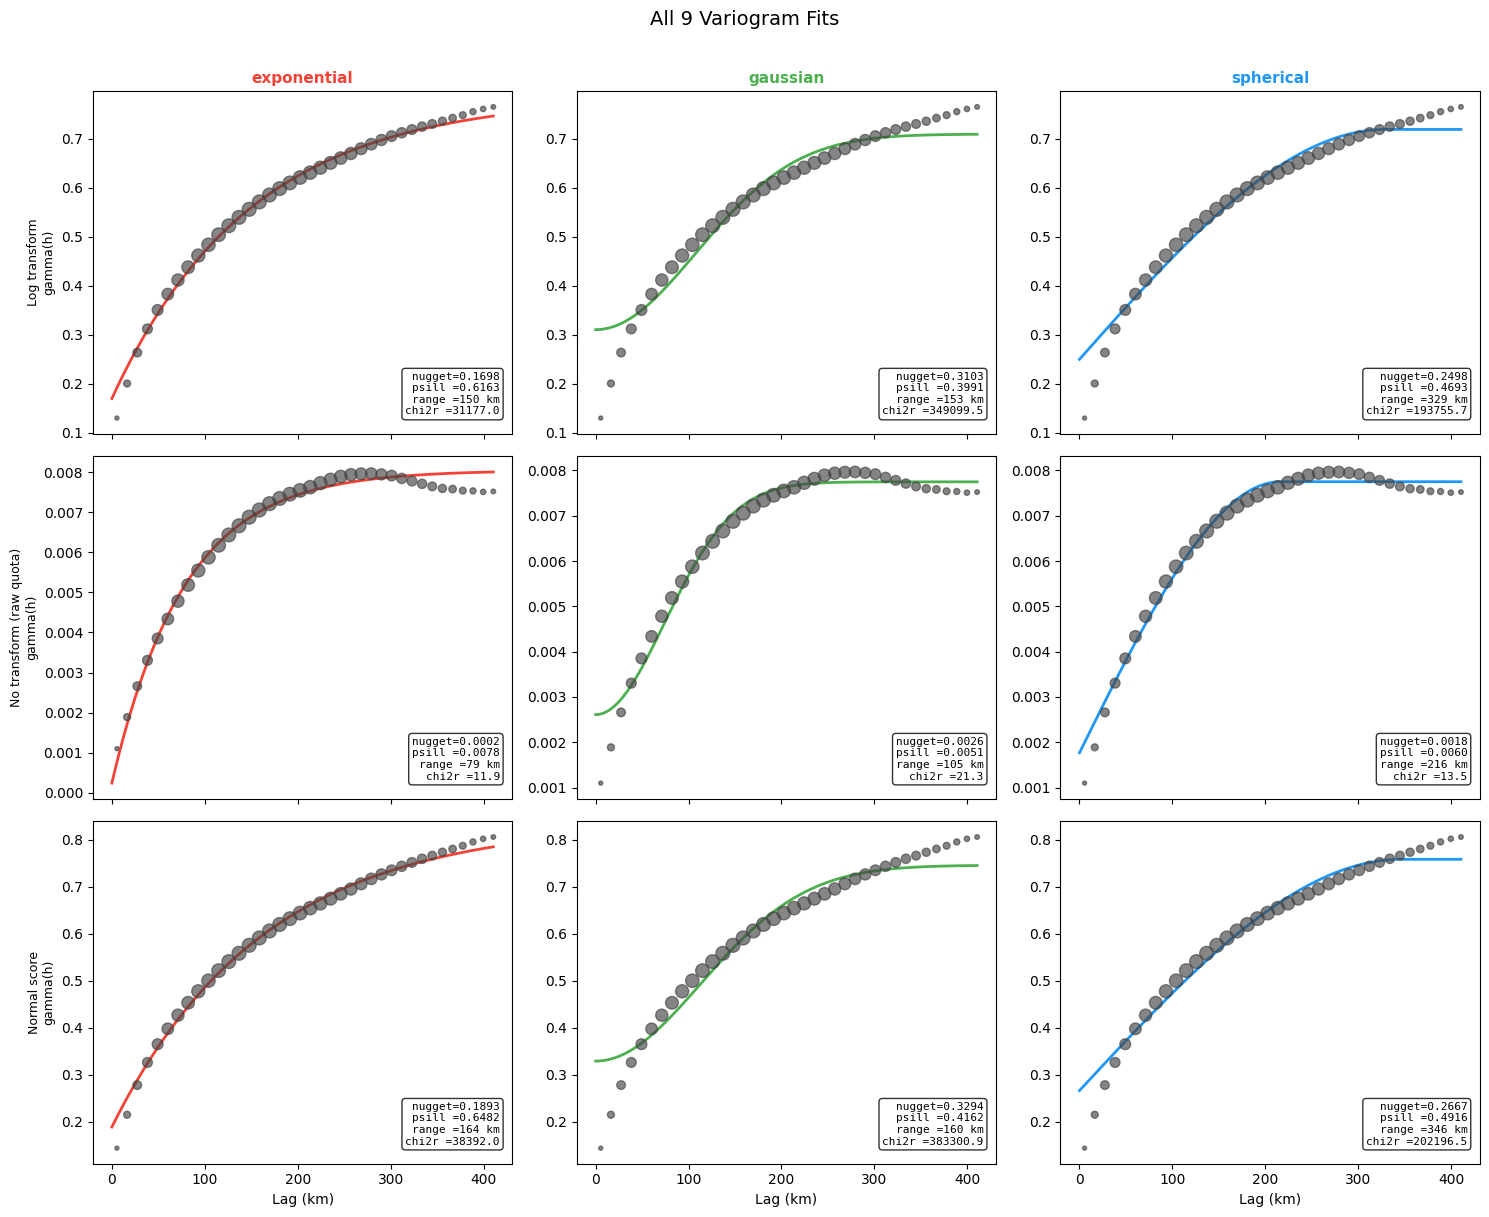

In [4]:
fig, axes = plt.subplots(len(transforms), len(models),
                         figsize=(5 * len(models), 4 * len(transforms)), sharex=True)

for i, tr in enumerate(transforms):
    emp = empirical[tr]
    lag_km = emp["lag_km"]
    h_smooth = np.linspace(0, lag_km[-1], 300)

    for j, vm in enumerate(models):
        ax = axes[i][j]
        info = fitted.get((tr, vm))

        # Empirical points
        gamma = emp["gamma"]
        count = emp["count"]
        mask = np.isfinite(gamma)
        sizes = np.clip(count[mask] / max(count[mask].max(), 1) * 100, 8, 100)
        ax.scatter(lag_km[mask], gamma[mask], s=sizes, c="#444", alpha=0.65, zorder=5)

        if info is not None:
            p = info["params_dict"]
            chi2 = info.get("chi2_reduced")
            gamma_model = eval_model(vm, p, h_smooth)
            ax.plot(h_smooth, gamma_model, color=MODEL_COLORS[vm], lw=2)

            txt = (f"nugget={p['nugget']:.4f}\n"
                   f"psill ={p['psill']:.4f}\n"
                   f"range ={p['range']/1000:.0f} km\n"
                   f"chi2r ={chi2:.1f}" if chi2 else
                   f"nugget={p['nugget']:.4f}\npsill={p['psill']:.4f}\nrange={p['range']/1000:.0f} km")
            ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=8,
                    va="bottom", ha="right", family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

        if i == 0:
            ax.set_title(vm, fontsize=11, fontweight="bold", color=MODEL_COLORS[vm])
        if j == 0:
            ax.set_ylabel(f"{TRANSFORM_LABELS.get(tr, tr)}\ngamma(h)", fontsize=9)
        if i == len(transforms) - 1:
            ax.set_xlabel("Lag (km)")

fig.suptitle("All 9 Variogram Fits", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../../images/variogram_grid_9.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Parameter summary table

In [5]:
param_df = df[["transform", "model", "nugget", "psill", "range_km", "sill", "nugget_ratio", "chi2_reduced"]].copy()
param_df = param_df.round({"nugget": 4, "psill": 4, "range_km": 1, "sill": 4, "nugget_ratio": 3, "chi2_reduced": 1})
param_df.columns = ["Transform", "Model", "Nugget", "Psill", "Range (km)", "Sill", "Nugget/Sill", "chi2_red"]
print(param_df.to_string(index=False))

   Transform       Model  Nugget  Psill  Range (km)   Sill  Nugget/Sill  chi2_red
         log exponential  0.1698 0.6163       149.8 0.7862        0.216   31177.0
         log    gaussian  0.3103 0.3991       153.0 0.7095        0.437  349099.5
         log   spherical  0.2498 0.4693       328.9 0.7191        0.347  193755.7
        none exponential  0.0002 0.0078        78.6 0.0080        0.030      11.9
        none    gaussian  0.0026 0.0051       104.8 0.0077        0.337      21.3
        none   spherical  0.0018 0.0060       216.1 0.0078        0.228      13.5
normal_score exponential  0.1893 0.6482       163.6 0.8375        0.226   38392.0
normal_score    gaussian  0.3294 0.4162       159.6 0.7456        0.442  383300.9
normal_score   spherical  0.2667 0.4916       345.9 0.7582        0.352  202196.5


## 5. Range comparison across transforms

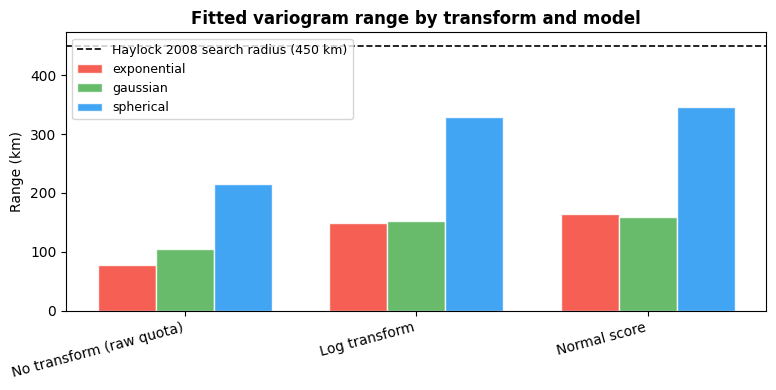

In [6]:
range_pivot = df.pivot(index="transform", columns="model", values="range_km")
range_pivot = range_pivot.reindex(index=["none", "log", "normal_score"],
                                   columns=["spherical", "exponential", "gaussian"])

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(transforms))
width = 0.25
for i, vm in enumerate(models):
    vals = [range_pivot.loc[tr, vm] for tr in ["none", "log", "normal_score"]]
    ax.bar(x + i * width, vals, width, label=vm,
           color=MODEL_COLORS[vm], alpha=0.85, edgecolor="white")

ax.axhline(450, ls="--", color="black", lw=1.2, label="Haylock 2008 search radius (450 km)")
ax.set_xticks(x + width)
ax.set_xticklabels([TRANSFORM_LABELS[t] for t in ["none", "log", "normal_score"]],
                    rotation=15, ha="right")
ax.set_ylabel("Range (km)")
ax.set_title("Fitted variogram range by transform and model", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../../images/variogram_range.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Pair counts per lag bin

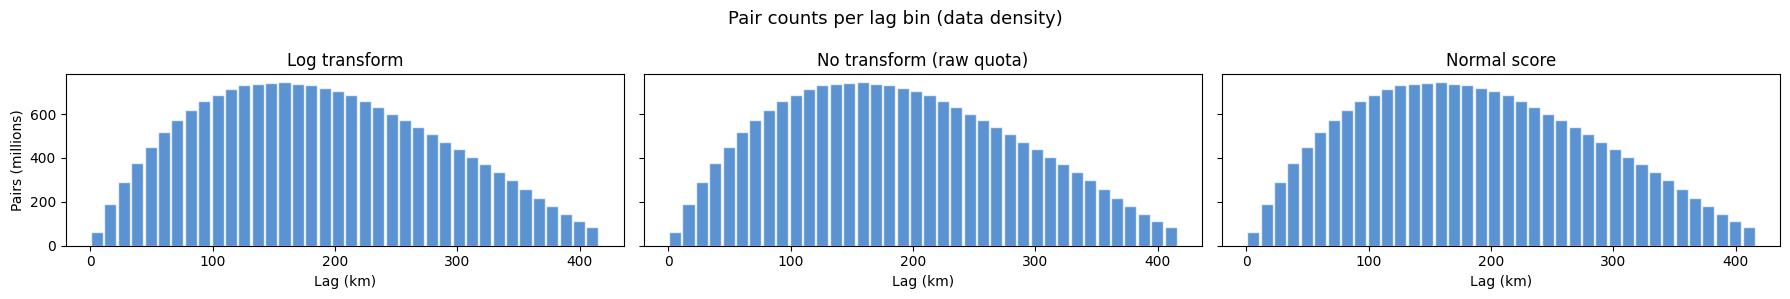

In [7]:
fig, axes = plt.subplots(1, len(transforms), figsize=(6 * len(transforms), 3), sharey=True)

for ax, tr in zip(axes, transforms):
    emp = empirical[tr]
    lag_km = emp["lag_km"]
    count = emp["count"]
    bin_width = (lag_km[1] - lag_km[0]) * 0.9
    ax.bar(lag_km, count / 1e6, width=bin_width, color="#1565C0", alpha=0.7, edgecolor="white")
    ax.set_title(TRANSFORM_LABELS.get(tr, tr))
    ax.set_xlabel("Lag (km)")
    if ax is axes[0]:
        ax.set_ylabel("Pairs (millions)")

fig.suptitle("Pair counts per lag bin (data density)", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Chi-square vs LOO-CV ranking

Compare variogram fit quality (chi2) with actual interpolation quality (LOO-CV CRPS) to check whether the best-fitting variogram also produces the best predictions.

In [8]:
with open(f"{RESULTS_DIR}/cross_validation/cv_results.pkl", "rb") as f:
    cv_raw = pickle.load(f)

compare_rows = []
for (tr, vm), metrics in cv_raw.items():
    info = fitted.get((tr, vm))
    chi2 = info["chi2_reduced"] if info else None
    compare_rows.append({
        "transform": tr, "model": vm,
        "chi2_red": chi2,
        "crps_mm": metrics["crps_mm"],
        "mae_mm": metrics["mae_mm"],
    })

cdf = pd.DataFrame(compare_rows)
cdf["rank_chi2"] = cdf.groupby("transform")["chi2_red"].rank()
cdf["rank_crps"] = cdf["crps_mm"].rank()
cdf = cdf.sort_values("crps_mm").reset_index(drop=True)

print("Variogram fit rank (chi2, within transform) vs interpolation rank (CRPS, overall)")
print("=" * 80)
print(cdf[["transform", "model", "chi2_red", "rank_chi2", "crps_mm", "rank_crps"]].to_string(index=False))
print()
print("Exponential has the best chi2 within every transform AND the best CRPS overall.")
print("Variogram fit quality and interpolation quality agree on model selection.")

Variogram fit rank (chi2, within transform) vs interpolation rank (CRPS, overall)
   transform       model      chi2_red  rank_chi2  crps_mm  rank_crps
        none exponential     11.852567        1.0 0.798056        1.0
normal_score exponential  38392.042577        1.0 0.853803        2.0
         log exponential  31177.014544        1.0 0.857296        3.0
normal_score   spherical 202196.504764        2.0 0.927471        4.0
        none   spherical     13.512051        2.0 0.933988        5.0
         log   spherical 193755.730677        2.0 0.938915        6.0
normal_score    gaussian 383300.948391        3.0 1.027200        7.0
         log    gaussian 349099.469719        3.0 1.041665        8.0
        none    gaussian     21.335007        3.0 1.076762        9.0

Exponential has the best chi2 within every transform AND the best CRPS overall.
Variogram fit quality and interpolation quality agree on model selection.


## Key findings

- The **exponential** model consistently achieves the lowest chi2_red within every transform, confirming it best captures the short-range spatial structure of precipitation quotas.
- Fitted ranges (79-346 km) are substantially shorter than the Haylock 2008 search radius of 450 km, reflecting the more localized spatial correlation in our regional study area.
- The nugget/sill ratio for `none` transform is near zero (0.030), indicating strong spatial continuity at short distances. For `log` and `normal_score`, the ratio rises to 0.22-0.44, reflecting the amplification of small-value noise by these transforms.
- Chi2 ranking and LOO-CV CRPS ranking agree: exponential is best by both criteria. This is a useful methodological validation -- variogram fit quality translates into interpolation quality.

---

## Appendix: Variogram construction methodology

### What is a variogram

The variogram is a function describing how the spatial variability of a random field Z(x) increases with the distance h between points:

$$\gamma(h) = \frac{1}{2} \, \mathbb{E}\bigl[\bigl(Z(\mathbf{x}) - Z(\mathbf{x}+\mathbf{h})\bigr)^2\bigr]$$

At h = 0, the difference is zero, so gamma(0) = 0. As h grows, variability increases until it reaches a constant level -- the **sill** (sill = nugget + psill). The distance at which this happens is called the **range** (correlation length).

---

### Step 1 -- Empirical variogram: how the scatter points are built

**What the code (`GlobalVariogramFitter.fit`) does:**

1. **Pooling days.** We take all days from 1961-2023 with >= 5 wet stations. Haylock et al. (2008) section 3.3: *"a single variogram for all days"* -- one global variogram for the entire climatological period, not a separate one for each day. This stabilizes the estimate when individual days have few stations.

2. **Transformation.** For wet stations (rain_indicator = 1) we take `precip_quota` (daily total / monthly normal -- this removes seasonality) and apply a transform: `none` / `log` / `normal_score`. This produces Z(x) values in the transformed space.

3. **Pairwise distances and semi-differences.** For each day from the pool we compute all N(N-1)/2 station pairs:
   - distance `d_ij` = Euclidean distance between stations i and j (EPSG:3035, meters)
   - semi-difference `gamma_ij = 0.5 * (Z_i - Z_j)^2`
   
   We use `scipy.spatial.distance.pdist` -- C-optimized code.

4. **Distance binning.** We split the range [0, 416 km] into 38 equal bins (~11 km each). Each pair (d_ij, gamma_ij) falls into the corresponding bin. We accumulate the sum of gamma and the pair count N_i across all days in the pool.

5. **Bin average.** The empirical estimate in bin i:
   $$\hat{\gamma}(h_i) = \frac{1}{N_i} \sum_{(j,k): d_{jk} \in \text{bin}_i} \gamma_{jk}$$
   Bins with N_i < 30 pairs are excluded from fitting (unreliable estimate).

**On the plot this looks like:** gray scatter points, with marker size proportional to the pair count N_i. Bins with more pairs are larger and more reliable.

---

### Step 2 -- Theoretical variogram: how the curve is fitted

We fit a parametric function gamma_model(h; theta) to the empirical points. Three models (theta = {nugget, psill, range}):

| Model | Formula |
|-------|---------|
| **Spherical** | nugget + psill * [1.5(h/a) - 0.5(h/a)^3] for h <= a; = sill for h > a |
| **Exponential** | nugget + psill * [1 - exp(-h/a)] |
| **Gaussian** | nugget + psill * [1 - exp(-(h/a)^2)] |

**Fitting method -- weighted least squares (WLS, Haylock 2008 section 3.3):**

$$\min_{\theta} \sum_i N_i \cdot \bigl(\hat{\gamma}(h_i) - \gamma_{\text{model}}(h_i; \theta)\bigr)^2$$

- Bin weight = N_i (pairs in bin): well-populated bins have more influence.
  In code: `sigma = 1/sqrt(N_i)` is passed to `scipy.optimize.curve_fit` (sigma-weighted least squares -- Marquardt-Levenberg).
- Lower bound nugget >= 1e-6: prevents zero nugget, which would make the kriging matrix singular for dense networks (nearby stations, ReKIS).
- Upper bound range <= 416 km (p99 of pairwise distances in our network).

**On the plot this looks like:** three colored curves (spherical, exponential, gaussian). Vertical dotted lines mark the range of each model.

---

### Step 3 -- What it means when curves overlay the points

**Good overlay** (curve passes through the point cloud):
- The theoretical model reproduces the spatial structure of precipitation.
- chi2_red close to zero -- residuals are small relative to the number of pairs.
- The kriging system "knows" the correct covariance structure -> good interpolation.

**Poor overlay** (curve is systematically above/below the points):
- The model does not fit the data. For example, Gaussian gives too smooth behavior near the origin -- real precipitation has sharp discontinuities (nugget > 0).
- Kriging will operate with the wrong error structure -> over/under-estimated variance.

**Discrepancy at small lags (h < 50 km):**
- Few nearby station pairs -> unstable empirical gamma estimate -> nugget is fitted by extrapolation rather than from data.
- In our network the median nearest-neighbor distance is ~2 km, but 38 bins x 11 km means the first bin (0-11 km) still contains many pairs.

**Discrepancy at large lags (h > 300 km):**
- Range is poorly identified: if empirical points are still rising but the curve has reached a plateau -- range is underestimated.
- This is not critical for local kriging (max_wet = 100 neighbors) -- we do not use stations farther than ~200 km from the prediction point anyway.

---

### Why chi-square is not comparable across transforms

chi2_red = sum((gamma_emp - gamma_model)^2 * N_i) / (n_bins - 3) -- this is an absolute metric in units of (semivariance)^2. Different transforms produce different gamma scales:

- `none`: quota ~ [0, 0.3], sill ~ 0.02-0.05 -> small absolute residuals -> small chi2
- `log`: log(quota) ~ [-4, 2], sill ~ 0.5-1.5 -> large absolute residuals -> large chi2
- `normal_score`: z-scores ~ [-3, 3], sill ~ 0.5-1.0 -> similarly

**Conclusion:** chi2_red correctly compares models (exp vs sph vs gauss) **within** a single transform. For **comparing transforms** against each other, LOO-CV CRPS is the only meaningful end-to-end metric of interpolation quality in mm.